<a href="https://colab.research.google.com/github/VasilievNichita/IA_LABS/blob/main/Lab_4_IA_Vasiliev_Nichita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Загружаем датасет с Kaggle
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("emmanuelleai/world-marathons-majors")

# Смотрим файлы внутри
files = os.listdir(path)
print(files)

# Загружаем основной CSV файл
df = pd.read_csv(os.path.join(path, files[0]), encoding='latin-1')

# Смотрим первые строки
df.head()

Using Colab cache for faster access to the 'world-marathons-majors' dataset.
['world_marathon_majors.csv', '.nfs000000005de434bc0000004f']


,year,winner,gender,country,time,marathon
0,2018,Dickson Chumba,Male,Kenya,02:05:30,Tokyo
1,2018,Birhane Dibaba,Female,Ethiopia,02:19:51,Tokyo
2,2017,Wilson Kipsang,Male,Kenya,02:03:58,Tokyo
3,2017,Sarah Chepchirchir,Female,Kenya,02:19:47,Tokyo
4,2016,Feyisa Lilesa,Male,Ethiopia,02:06:56,Tokyo


In [ ]:
# ================================
# ПРИВОДИМ НАЗВАНИЯ К НОРМАЛЬНОМУ ВИДУ
# ================================

# Делаем все названия колонок маленькими (чтобы не было ошибок типа Time/time)
df.columns = df.columns.str.lower()

# Проверяем колонки
print(df.columns)


# ================================
# ПРЕОБРАЗОВАНИЕ ВРЕМЕНИ В ЧИСЛО
# ================================

# Переводим строковое время (hh:mm:ss) в секунды
df['time_sec'] = pd.to_timedelta(df['time']).dt.total_seconds()

# Проверяем
df[['time', 'time_sec']].head()


# ================================
# СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# ================================

# 1 = быстрый (меньше медианы), 0 = медленный
df['fast_runner'] = (df['time_sec'] < df['time_sec'].median()).astype(int)

# Проверяем баланс классов
print(df['fast_runner'].value_counts())


# ================================
# (ОПЦИОНАЛЬНО) УДАЛЯЕМ СТРОКОВОЕ ВРЕМЯ
# ================================

# Оно больше не нужно
df = df.drop('time', axis=1)


# ================================
# ПРОВЕРКА
# ================================

df.head()
df.info()

Index(['year', 'winner', 'gender', 'country', 'time', 'marathon'], dtype='object')
fast_runner
1    268
0    268
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         536 non-null    int64  
 1   winner       536 non-null    object 
 2   gender       536 non-null    object 
 3   country      536 non-null    object 
 4   marathon     536 non-null    object 
 5   time_sec     536 non-null    float64
 6   fast_runner  536 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 29.4+ KB


In [ ]:
# Сколько строк в датасете
len(df)

536

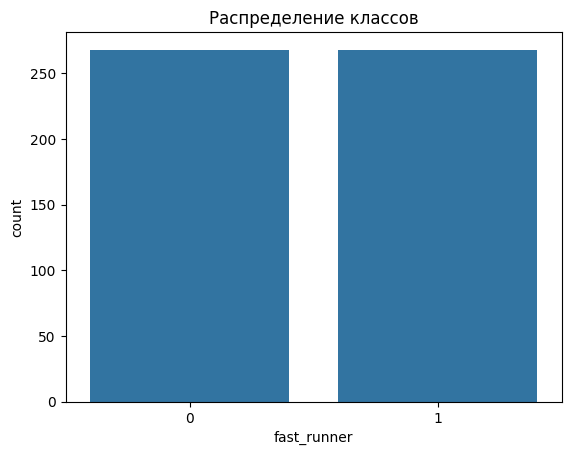

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot Распределение целевой переменной
sns.countplot(x='fast_runner', data=df)
plt.title("Распределение классов")
plt.show()

In [ ]:
# Процентное соотношение классов
df['fast_runner'].value_counts(normalize=True)

,proportion
fast_runner,
1,0.5
0,0.5


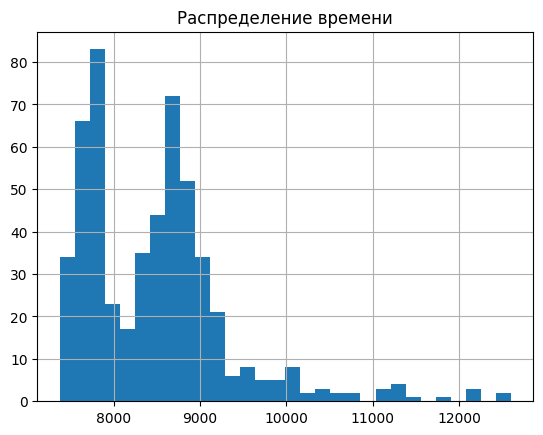

In [ ]:
# Распределение времени марафона Гистограмма
df['time_sec'].hist(bins=30)
plt.title("Распределение времени")
plt.show()

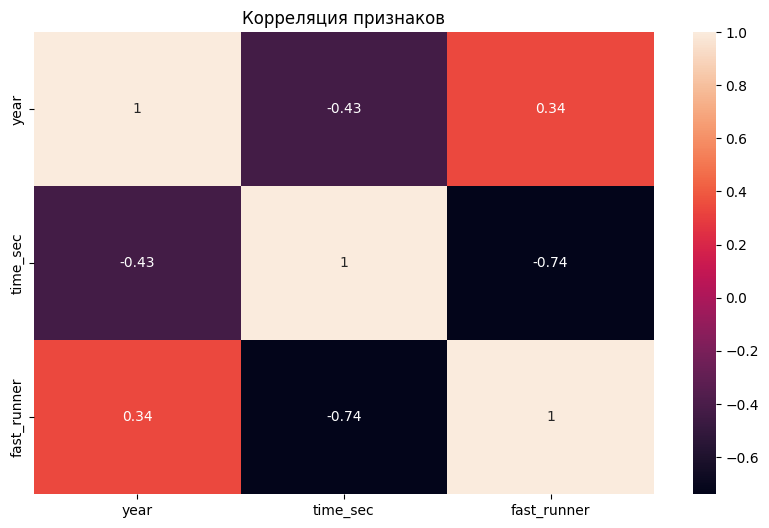

In [ ]:
# Считаем корреляцию между числовыми признаками
corr = df.corr(numeric_only=True)

# Тепловая карта
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Корреляция признаков")
plt.show()

In [ ]:
# Смотрим какие признаки сильнее всего влияют на Time
corr['time_sec'].sort_values(ascending=False)

,time_sec
time_sec,1.000000
year,-0.427552
fast_runner,-0.739960


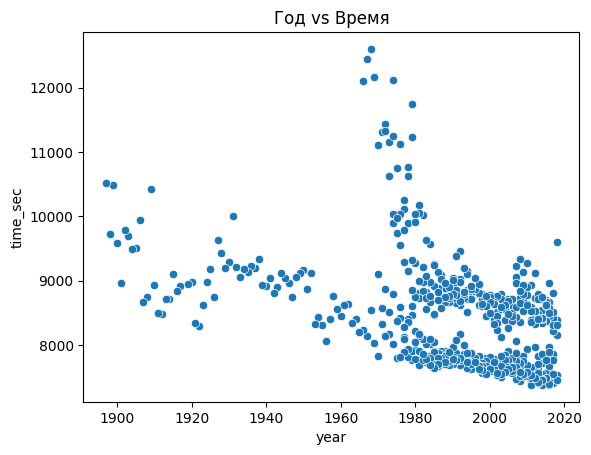

In [ ]:
# Scatter plot: год vs время
sns.scatterplot(x='year', y='time_sec', data=df)
plt.title("Год vs Время")
plt.show()

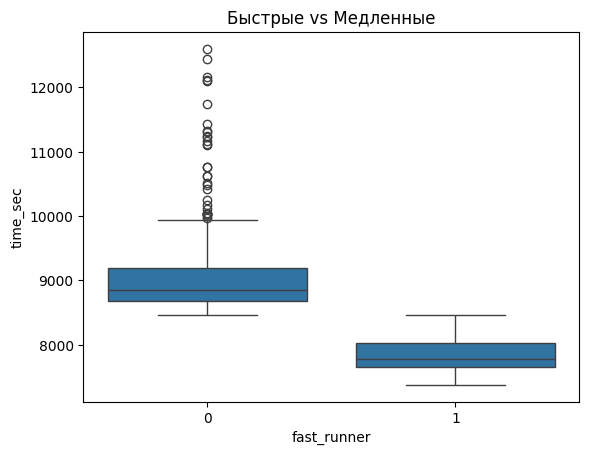

In [ ]:
# Сравнение времени между классами
sns.boxplot(x='fast_runner', y='time_sec', data=df)
plt.title("Быстрые vs Медленные")
plt.show()

In [ ]:
# Статистика по классам
df.groupby('fast_runner')['time_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
fast_runner,,,,,,,,
0,268.0,9123.294776,761.845388,8469.0,8685.5,8856.5,9190.50,12600.0
1,268.0,7856.194030,292.306852,7377.0,7660.0,7783.0,8032.75,8466.0


In [ ]:
# Статистика по классам
df.groupby('fast_runner')['time_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
fast_runner,,,,,,,,
0,268.0,9123.294776,761.845388,8469.0,8685.5,8856.5,9190.50,12600.0
1,268.0,7856.194030,292.306852,7377.0,7660.0,7783.0,8032.75,8466.0


In [ ]:
# Список категориальных колонок
df.select_dtypes(include='object').columns

Index(['winner', 'gender', 'country', 'marathon'], dtype='object')

In [ ]:
# Пример анализа категориального признака
df['gender'].value_counts()

,count
gender,
Male,303
Female,233


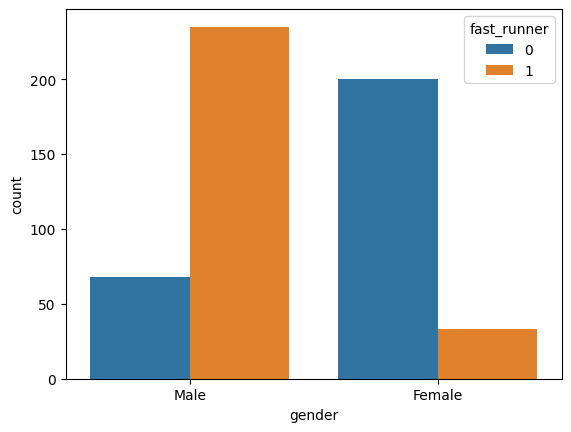

In [ ]:
# Сравнение пола и скорости
sns.countplot(x='gender', hue='fast_runner', data=df)
plt.show()

In [ ]:
# Количество пропусков
df.isnull().sum()

,0
year,0
winner,0
gender,0
country,0
marathon,0
time_sec,0
fast_runner,0


In [ ]:
# Процент пропусков
(df.isnull().sum() / len(df)) * 100

,0
year,0.0
winner,0.0
gender,0.0
country,0.0
marathon,0.0
time_sec,0.0
fast_runner,0.0


In [ ]:
# Удаляем строки с пропусками
df = df.dropna()

In [ ]:
# Удаляем неинформативный признак (имя победителя)
df = df.drop('winner', axis=1, errors='ignore')

In [ ]:
# Смотрим сколько уникальных значений в категориальных колонках
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

In [ ]:
# Преобразуем категориальные признаки в числа
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Проверяем структуру данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Columns: 359 entries, year to marathon_Tokyo
dtypes: bool(356), float64(1), int64(2)
memory usage: 199.0 KB


In [ ]:
from sklearn.model_selection import train_test_split
#Train/Test split
# Делим на признаки и целевую переменную
X = df.drop('fast_runner', axis=1)
y = df['fast_runner']

# Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Номрализация
# Создаем scaler
scaler = MinMaxScaler()

# Обучаем только на train (без утечки данных!)
X_train = scaler.fit_transform(X_train)

# Применяем к test
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Модель
# Создаем модель нейросети
model = Sequential()

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Компиляция модели
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Обучаем модель
history = model.fit(
    X_train, y_train,
    epochs=25,
    validation_data=(X_test, y_test)
)

Epoch 1/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6519 - loss: 0.6833 - val_accuracy: 0.6759 - val_loss: 0.6795
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8248 - loss: 0.6620 - val_accuracy: 0.7870 - val_loss: 0.6624
Epoch 3/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8808 - loss: 0.6316 - val_accuracy: 0.8148 - val_loss: 0.6372
Epoch 4/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8949 - loss: 0.5870 - val_accuracy: 0.8426 - val_loss: 0.5995
Epoch 5/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8995 - loss: 0.5238 - val_accuracy: 0.8611 - val_loss: 0.5490
Epoch 6/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9252 - loss: 0.4469 - val_accuracy: 0.8519 - val_loss: 0.4905
Epoch 7/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9322 - loss: 0.3684 - val_accuracy: 0.8426 - val_loss: 0.4357
Epoch 8/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9439 - loss: 0.2962 - val_accuracy: 0.8611 - val_loss

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Предсказания
predictions = (model.predict(X_test) > 0.5).astype(int)

# Матрица ошибок
print(confusion_matrix(y_test, predictions))

# Отчет классификации
print(classification_report(y_test, predictions))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[38 12]
 [ 3 55]]
              precision    recall  f1-score   support

           0       0.93      0.76      0.84        50
           1       0.82      0.95      0.88        58

    accuracy                           0.86       108
   macro avg       0.87      0.85      0.86       108
weighted avg       0.87      0.86      0.86       108



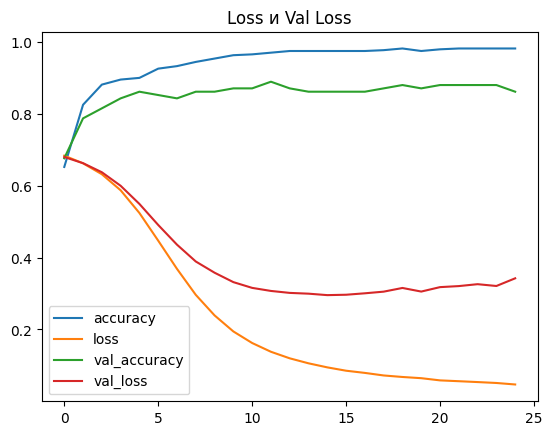

In [ ]:
# График обучения
losses = pd.DataFrame(history.history)

losses.plot()
plt.title("Loss и Val Loss")
plt.show()